# Popular Video Games 1980 - 2023

( Dataset [disponible en Kaggle](https://www.kaggle.com/datasets/arnabchaki/popular-video-games-1980-2023/data))


## Presentación del dataset

En este cuaderno vamos a trabajar con el dataset **"Popular Video Games 1980-2023"**, publicado en Kaggle por el usuario **arnabchaki**. Se trata de un conjunto de datos que reúne información sobre videojuegos lanzados a lo largo de más de cuatro décadas, desde 1980 hasta 2023. Incluye datos como fechas de lanzamiento, valoraciones de usuarios y críticas especializadas, entre otros atributos relevantes.

Este tipo de dataset resulta interesante para una primera aproximación al trabajo con datos en Pandas porque es un tema familiar para todos y, al mismo tiempo, permite observar varias de las características habituales de un conjunto de datos real. No estamos frente a una tabla “perfecta” construida solo para practicar, sino ante información recopilada y organizada para analizar productos culturales muy diversos: juegos de distintas épocas, plataformas, géneros y niveles de recepción por parte del público y la crítica. Esa diversidad lo vuelve interesante para **explorar**, **limpiar**, **resumir** y **visualizar**.

El período cubierto por el dataset comienza en los años de consolidación de la industria del videojuego, atraviesa momentos clave como la expansión de las consolas domésticas en los años 80, las transformaciones posteriores del mercado y llega hasta una etapa reciente marcada por la enorme variedad de estudios, plataformas y comunidades de jugadores. Por eso, además de servir para practicar herramientas de análisis de datos, este dataset permite pensar cómo cambian los productos culturales y tecnológicos a lo largo del tiempo.

En términos didácticos, este conjunto de datos nos va a ayudar a introducir varias preguntas básicas que aparecen en casi cualquier trabajo de ciencia de datos o machine learning:

- *¿qué representa cada fila?*,
- *¿qué información aporta cada columna?*,
- *¿qué tipo de datos contiene cada variable?*,
- *¿hay valores faltantes?*,
- *¿hay campos numéricos, textuales o temporales?*,
- *¿qué columnas parecen más útiles para describir, comparar o predecir?*

Como veremos, antes de pensar en construir modelos, siempre conviene detenerse en este primer paso: **conocer bien el dataset**.

En esta etapa inicial no nos interesa memorizar todas sus columnas, sino empezar a desarrollar una mirada analítica. Queremos aprender a “leer” una tabla de datos: **reconocer su origen, interpretar su estructura y detectar qué tipo de preguntas podría ayudarnos a responder**. Pandas será nuestra herramienta principal para hacer esa primera exploración.

## Importar librerías para trabajar con los datos

Antes de comenzar a analizar un dataset, necesitamos importar algunas librerías de Python que nos van a ayudar a leer los datos, organizarlos, representarlos gráficamente y realizar algunos cálculos o pruebas estadísticas básicas.

- La librería principal en este trabajo será **Pandas**, que importamos como `pd`. Pandas está pensada para trabajar con datos tabulares, es decir, con información organizada en filas y columnas, como si fuera una planilla. Gracias a ella podemos abrir archivos CSV, inspeccionar su estructura, filtrar registros, seleccionar columnas y resumir información de manera muy cómoda.

- También vamos a usar **NumPy**, que importamos como `np`. Esta librería es muy importante en el ecosistema de ciencia de datos de Python, ya que ofrece estructuras y operaciones numéricas eficientes. Aunque en esta primera aproximación tal vez no la usemos intensivamente, es habitual tenerla disponible porque muchas operaciones sobre datos numéricos se apoyan en ella.

- Para la creación de gráficos vamos a importar **Matplotlib**, en particular su módulo `pyplot`, con el nombre `plt`. Esta librería nos permitirá construir visualizaciones sencillas, como gráficos de barras, histogramas o gráficos de dispersión, que son fundamentales para explorar un conjunto de datos y detectar patrones generales.

- Además, incorporamos **SciPy**, en este caso mediante su módulo de estadística, que importamos como `st`. Esta librería resulta útil cuando queremos realizar cálculos estadísticos un poco más específicos o aplicar algunas pruebas que van más allá de las operaciones básicas incluidas en `Pandas` o `NumPy`.

- Junto con eso, importamos también el módulo **math**, con el alias `mt`, que forma parte de la biblioteca estándar de Python. Nos puede resultar útil para realizar ciertos cálculos matemáticos puntuales de manera clara y directa.

- Por último, vamos a usar **kagglehub**, una librería que facilita la descarga de datasets alojados en Kaggle directamente desde el cuaderno. Esto nos permite trabajar de una forma más ágil, sin necesidad de descargar manualmente los archivos y subirlos luego al entorno de trabajo.

Estas herramientas forman una base muy habitual en análisis de datos y machine learning. No es necesario dominarlas todas desde el comienzo: la idea es ir viéndolas en uso, entendiendo para qué sirve cada una a medida que avancemos.

In [15]:
# Librerías para el manejo de datos
import pandas as pd
import numpy as np

# Librerías para creación de gráficos
import matplotlib.pyplot as plt

# Librerías para pruebas estadísticas
from scipy import stats as st
import math as mt

# Libreria para importar directamente desde Kaggle
import kagglehub

# Extra: acceso a comandos del Sistema Operativo
import os

## Cargar el dataset

El siguiente bloque de código permite cargar el dataset con el que vamos a trabajar. Para hacerlo, sigue una estrategia que nos puede ser útil en otros proyectos: primero intenta abrir el archivo `games.csv` desde el entorno local del cuaderno, y solo si no lo encuentra, lo descarga automáticamente desde Kaggle.

La instrucción `try` marca el comienzo de un intento. Dentro de ese bloque usamos `pd.read_csv("games.csv")`, que le pide a Pandas que lea un archivo CSV llamado `games.csv` y lo guarde en la variable `games`. Si el archivo está disponible en el entorno actual, la carga se realiza sin problemas y se muestra un mensaje indicando que el dataset fue cargado desde un archivo local.

Si ese intento falla, el programa pasa automáticamente al bloque `except`. En este caso, eso significa que el archivo no estaba disponible en el entorno de trabajo, por lo que el código informa esta situación y luego procede a descargar el dataset desde Kaggle.

Para realizar la descarga se utiliza la función `kagglehub.dataset_download(...)`, indicando el identificador del dataset que queremos obtener. Esa función devuelve la ruta de la carpeta donde quedó descargado el contenido. Luego, con `os.path.join(...)`, se construye la ruta completa al archivo `games.csv` dentro de esa carpeta.

Finalmente, se vuelve a usar `pd.read_csv(...)`, pero esta vez con la ruta completa del archivo descargado. De ese modo, el dataset queda igualmente cargado en la variable `games`, aunque no hubiera estado disponible desde el comienzo.

Este enfoque tiene una ventaja importante: **hace que el cuaderno sea más flexible y reutilizable**. Puede funcionar tanto si el archivo ya está presente en el entorno como si todavía no fue descargado. En otras palabras, el código se adapta a la situación y resuelve automáticamente un problema frecuente al trabajar en Colab o en notebooks compartidos.

In [16]:
# Intentamos abrir el archivo si ya está disponible en el entorno
try:
    games = pd.read_csv("games.csv")
    print("Dataset cargado desde el archivo local 'games.csv'")
except Exception:
    print("No se encontró 'games.csv' en el entorno local.")
    print("Descargando dataset desde Kaggle...")

    ruta_dataset = kagglehub.dataset_download("arnabchaki/popular-video-games-1980-2023")
    ruta_csv = os.path.join(ruta_dataset, "games.csv")

    games = pd.read_csv(ruta_csv)
    print("Dataset descargado y cargado correctamente desde Kaggle")

Dataset cargado desde el archivo local 'games.csv'


# Exploración inicial de los datos

## Ver las primeras filas del dataset

Una vez cargado el archivo, suele ser conveniente dar un primer vistazo a su contenido. Para eso usamos:

```python
display(games.head())
````

La línea `display(games.head())` muestra las primeras cinco filas del DataFrame `games`. Recordemos que un **DataFrame** es una estructura de Pandas parecida a una tabla, con filas y columnas.

La función `head()` devuelve, por defecto, las primeras cinco filas del conjunto de datos. Esto resulta muy útil porque permite hacer una inspección rápida sin necesidad de mostrar toda la tabla completa. Gracias a esa vista inicial podemos empezar a responder preguntas como estas:

* ¿Qué columnas tiene el dataset?
* ¿Qué tipo de información parece guardar cada una?
* ¿Los datos se ven razonables?
* ¿Hay valores vacíos o extraños a simple vista?
* ¿Cómo está organizada cada fila?

Es importante señalar que cada **fila** suele representar un registro individual del dataset. En este caso, cada fila corresponde a un videojuego. Las **columnas**, en cambio, representan atributos o características de esos videojuegos, como su nombre, fecha de lanzamiento, puntuaciones, género, plataforma u otros datos incluidos en el archivo.

> La salida de `games.head()` no se usa para hacer un análisis profundo todavía, sino para tener una **primera impresión general** del dataset y comenzar a familiarizarnos con su estructura.

In [17]:
# --------------------------------------------------------------
# Primer vistazo al dataset
# --------------------------------------------------------------
print("\nPrimeras 5 filas del dataset:")
display(games.head())



Primeras 5 filas del dataset:


,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K


## Conocer las dimensiones del dataset

Después de observar las primeras filas, otro paso muy habitual es averiguar qué tamaño tiene el conjunto de datos. Para eso usamos:

```python
print(games.shape)
````

La línea utiliza `games.shape`, un atributo de Pandas que devuelve una tupla con dos valores: en primer lugar, la cantidad de filas del DataFrame y, en segundo lugar, la cantidad de columnas.


Este dato es importante porque nos da una idea general del volumen de información con la que vamos a trabajar. Las filas nos indican cuántos registros hay en total; en este caso, cuántos videojuegos aparecen en la tabla. Las columnas nos muestran cuántas variables o características distintas se registran para cada videojuego.

Conocer las dimensiones del dataset es útil desde el comienzo porque permite responder preguntas muy básicas pero relevantes, como por ejemplo:

* ¿Estamos frente a un dataset pequeño o grande?
* ¿Tiene muchas variables o solo unas pocas?
* ¿Será fácil recorrerlo visualmente o necesitaremos resumirlo?
* ¿Cuánta información tenemos disponible antes de comenzar el análisis?

En otras palabras, `shape` nos ofrece una vista muy sintética de la estructura general del dataset y complementa muy bien la inspección inicial que hicimos con `head()`.

In [18]:
print("\nDimensiones del dataset (filas, columnas):")
print(games.shape)


Dimensiones del dataset (filas, columnas):
(1512, 14)


## Revisión de distribuciones estadísticas para las variables numéricas

Luego de observar las primeras filas y conocer las dimensiones generales del dataset, conviene dar un paso más y obtener un resumen estadístico de sus variables numéricas. Para eso usamos:

```python
display(games.describe())
````

La instrucción `games.describe()` genera una tabla con **estadísticas descriptivas básicas de las columnas numéricas** del DataFrame. De manera predeterminada, `Pandas` calcula este resumen solo para aquellas variables que reconoce como numéricas.

Entre los valores que suelen aparecer en esta salida se encuentran los siguientes:

* **count**: indica cuántos valores no nulos hay en cada columna.
* **mean**: representa el promedio de los valores.
* **std**: muestra la desviación estándar, es decir, una medida de cuánto se dispersan los datos respecto del promedio.
* **min**: indica el valor mínimo observado.
* **25%**: corresponde al primer cuartil; es el valor por debajo del cual se encuentra aproximadamente el 25% de los datos.
* **50%**: corresponde a la mediana, es decir, el valor central de la distribución.
* **75%**: corresponde al tercer cuartil; por debajo de él se encuentra aproximadamente el 75% de los datos.
* **max**: indica el valor máximo observado.

Este resumen no reemplaza a un análisis más detallado, pero resulta muy útil como primera aproximación. Nos permite detectar rápidamente cuestiones importantes, por ejemplo si una variable tiene pocos datos disponibles, si sus valores se concentran en cierto rango, si presenta mucha dispersión o si hay valores extremos que llaman la atención.

In [19]:
print("\nResumen estadístico de las variables numéricas:")
display(games.describe())


Resumen estadístico de las variables numéricas:


,Unnamed: 0,Rating
count,1512.000000,1499.000000
mean,755.500000,3.719346
std,436.621117,0.532608
min,0.000000,0.700000
25%,377.750000,3.400000
50%,755.500000,3.800000
75%,1133.250000,4.100000
max,1511.000000,4.800000


## Ver los nombres de las columnas

Otra forma muy útil de empezar a conocer un dataset es observar los nombres de sus columnas. Para eso usamos:

```python
display(games.columns)
````

Las columnas representan las distintas variables o atributos registrados en la tabla. En este caso, cada una de ellas describe algún aspecto de los videojuegos incluidos en el dataset.

La salida de `games.columns` nos muestra el conjunto de nombres de columnas del DataFrame.

Revisar las columnas es un paso importante al comienzo del análisis porque ayuda a responder preguntas como estas:

- ¿qué variables tenemos?,
- ¿cuáles parecen numéricas y cuáles textuales?,
- ¿hay nombres claros o conviene renombrarlos más adelante?,
- ¿qué columnas podrían ser útiles para explorar, comparar o graficar?

En esta etapa, el objetivo no es estudiar cada variable en profundidad, sino familiarizarnos con la estructura general del dataset y reconocer qué tipo de información contiene.


In [20]:
print("\nNombres de las columnas:")
display(games.columns)


Nombres de las columnas:


Index(['Unnamed: 0', 'Title', 'Release Date', 'Team', 'Rating', 'Times Listed',
       'Number of Reviews', 'Genres', 'Summary', 'Reviews', 'Plays', 'Playing',
       'Backlogs', 'Wishlist'],
      dtype='object')

## Obtener información general del dataset

Después de revisar los nombres de las columnas, conviene observar un resumen más técnico de la estructura del DataFrame. Para eso usamos:

```python
games.info()
````

Este método muestra **información general sobre el dataset**, incluyendo la cantidad total de filas, los nombres de las columnas, la cantidad de valores no nulos en cada una y el tipo de dato que `Pandas` asignó a cada variable.

Esta salida es útil en una primera exploración porque permite detectar si hay columnas con datos faltantes y también comprobar cómo está interpretando `Pandas` cada campo. Por ejemplo, una columna puede haber sido leída como numérica, textual o temporal, y eso influye directamente en las operaciones que podremos realizar después.

Revisar `info()` ayuda a construir una primera imagen estructural del dataset. No nos muestra el contenido detallado de las filas, pero sí nos permite entender cómo está organizada la tabla y qué clase de datos contiene cada columna.

In [21]:
print("\nInformación general del dataset:")
games.info()


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   object 
 2   Release Date       1512 non-null   object 
 3   Team               1511 non-null   object 
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   object 
 6   Number of Reviews  1512 non-null   object 
 7   Genres             1512 non-null   object 
 8   Summary            1511 non-null   object 
 9   Reviews            1512 non-null   object 
 10  Plays              1512 non-null   object 
 11  Playing            1512 non-null   object 
 12  Backlogs           1512 non-null   object 
 13  Wishlist           1512 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 165.5+ KB


### Tipos de datos más frecuentes:

- `int64`:  Se utiliza para números enteros, es decir, valores sin parte decimal. Por ejemplo: `1`, `25`, `1980`.

- `float64`:  Se utiliza para números decimales o reales. Por ejemplo: `3.14`, `8.5`, `1999.0`.

- `object`:  Es un tipo muy habitual en Pandas para columnas de texto. También puede aparecer cuando una columna contiene datos mezclados o cuando Pandas no puede asignarle un tipo más específico.

- `bool`:  Representa valores lógicos: `True` o `False`.

- `datetime64[ns]`:  Se utiliza para fechas y horas. Si una columna tiene este tipo, significa que Pandas la reconoce como información temporal.

- `timedelta[ns]`:  Representa intervalos de tiempo o duraciones, por ejemplo la diferencia entre dos fechas.

- `category`:  Se usa para variables categóricas, es decir, columnas que toman un conjunto limitado de valores repetidos, como por ejemplo géneros, regiones o plataformas.

- `string`:  Es un tipo específico para cadenas de texto. En algunos casos puede aparecer en lugar de `object`.

- `Int64`:  Es un tipo entero que admite valores faltantes. Se parece a `int64`, pero es más flexible cuando hay celdas vacías.

- `Float64`:  Es similar a `float64`, pero permite también valores faltantes.

- `boolean`:  Es similar a `bool`, pero admite además valores faltantes.

En una primera exploración de datos, los tipos que más suelen aparecer y que conviene reconocer desde el comienzo son `int64`, `float64`, `object` y, en algunos casos, `datetime64[ns]`.

## Revisar valores faltantes

En un dataset real no siempre todas las celdas contienen información. A veces faltan datos porque no fueron registrados, porque no estaban disponibles en la fuente original o porque hubo algún problema durante la recolección o la carga.

Por eso, después de observar la estructura general del DataFrame, conviene revisar si existen valores faltantes y en qué columnas aparecen.

Para hacerlo usamos `isnull().sum()`. La expresión `isnull()` genera, para cada celda del DataFrame, un valor lógico: `True` si el dato está ausente y `False` si está presente. Luego, al aplicar `sum()`, Pandas cuenta cuántos valores faltantes hay en cada columna.

Esta revisión es importante porque nos permite detectar rápidamente si una variable está completa o si tiene celdas vacías que más adelante podrían afectar el análisis, los gráficos o los modelos.

En esta etapa inicial no necesariamente vamos a corregir esos faltantes. Primero nos interesa identificarlos y tomar conciencia de su presencia dentro del dataset.

In [23]:
print("\nValores faltantes por columna:")
display(games.isnull().sum())

# Variante con salida ordenada:
# display(games.isnull().sum().sort_values(ascending=False))


Valores faltantes por columna:


,0
Unnamed: 0,0
Title,0
Release Date,0
Team,1
Rating,13
Times Listed,0
Number of Reviews,0
Genres,0
Summary,1
Reviews,0


,0
Rating,13
Team,1
Summary,1
Title,0
Release Date,0
Unnamed: 0,0
Times Listed,0
Number of Reviews,0
Genres,0
Reviews,0


## Distinguir variables numéricas y categóricas

No todas las columnas de un dataset representan el mismo tipo de información. Algunas contienen valores numéricos sobre los que podemos calcular **promedios**, **mínimos**, **máximos** o **desvíos**. Otras, en cambio, contienen texto o **categorías**, y suelen analizarse mediante conteos, frecuencias o agrupamientos.

Por eso resulta útil separar las variables numéricas de las no numéricas en una etapa temprana del análisis.

Con `select_dtypes()` podemos pedirle a `Pandas` que seleccione columnas según su tipo de dato.
- Si usamos `include="number"`, obtenemos las columnas numéricas.
- Si usamos `exclude="number"`, obtenemos las columnas que no son numéricas, como textos, categorías o fechas interpretadas de otra manera.

Esta distinción es importante porque orienta el tipo de preguntas que podemos hacer sobre cada variable y también los métodos de análisis o visualización que conviene aplicar después.

In [24]:
print("\nColumnas numéricas:")
display(games.select_dtypes(include="number").columns)

print("\nColumnas no numéricas:")
display(games.select_dtypes(exclude="number").columns)


Columnas numéricas:


Index(['Unnamed: 0', 'Rating'], dtype='object')


Columnas no numéricas:


Index(['Title', 'Release Date', 'Team', 'Times Listed', 'Number of Reviews',
       'Genres', 'Summary', 'Reviews', 'Plays', 'Playing', 'Backlogs',
       'Wishlist'],
      dtype='object')

## Explorar una variable numérica

Una vez identificadas las columnas numéricas del dataset, podemos comenzar a analizarlas de forma más específica. En este caso, una variable relevante para una primera exploración es `Rating`, ya que representa una puntuación asociada a cada videojuego.

Una forma muy útil de observar el comportamiento de una variable numérica es mediante un **histograma**. Este tipo de gráfico agrupa los valores en intervalos y muestra cuántos registros caen dentro de cada uno. De ese modo, permite ver si los datos se concentran en ciertos rangos, si están más dispersos o si aparecen valores poco frecuentes.

En esta etapa no buscamos hacer una interpretación estadística profunda, sino obtener una primera impresión visual de cómo se distribuyen los valores de la variable.

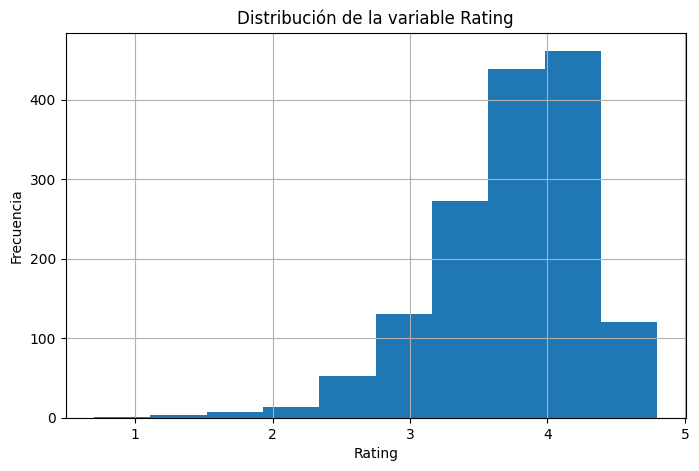

In [25]:
plt.figure(figsize=(8, 5))
games["Rating"].hist(bins=10)
plt.title("Distribución de la variable Rating")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.show()

## Explorar una variable categórica

Además de las variables numéricas, en un dataset también suelen aparecer variables categóricas o textuales. Estas no se analizan mediante promedios o desvíos, sino observando qué valores aparecen y con qué frecuencia.

Para eso podemos usar `value_counts()`, un método que cuenta cuántas veces aparece cada valor en una columna.

En este caso vamos a aplicarlo sobre la columna `Genres`. Así podremos ver cuáles son los géneros que aparecen con mayor frecuencia en el dataset.

Como puede haber muchos valores distintos, vamos a mostrar solo los 10 más frecuentes. De esta manera, la salida resulta más clara y más fácil de interpretar en una primera exploración.

In [26]:
print("\nLos 10 valores más frecuentes de la columna 'Genres':")
display(games["Genres"].value_counts().head(10))


Los 10 valores más frecuentes de la columna 'Genres':


,count
Genres,
"['Adventure', 'RPG']",154
"['Adventure', 'Platform']",107
"['Adventure', 'Shooter']",82
['Shooter'],72
"['Adventure', 'RPG', 'Turn Based Strategy']",48
['Adventure'],44
"['Adventure', 'Brawler']",40
['RPG'],37
['Platform'],34


## Cierre de esta primera exploración

En este cuaderno realizamos una primera aproximación al dataset con el que vamos a trabajar. Antes de pensar en modelos o análisis más avanzados, nos detuvimos en una etapa fundamental: **conocer los datos**.

A lo largo de esta exploración inicial vimos cómo cargar el archivo, observar sus primeras filas, conocer sus dimensiones, revisar los nombres de las columnas, identificar sus tipos de datos y detectar la presencia de valores faltantes. También realizamos una primera mirada sobre una variable numérica y una variable categórica para empezar a reconocer la forma general en que está organizada la información.

Este tipo de análisis preliminar es un paso muy importante en cualquier trabajo de **ciencia de datos** o **machine learning**. Nos permite familiarizarnos con el dataset, comprender qué clase de información contiene y prepararnos para una etapa posterior en la que será necesario revisar, limpiar y transformar los datos antes de analizarlos con mayor profundidad.

En el próximo cuaderno nos vamos a concentrar justamente en esa nueva etapa: **la preparación de los datos**.